In [13]:
import pandas as pd
df=pd.read_csv("../data/cleaned_data.csv")
df.head()

,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_status,connection_count,destination_server_different_host_rate,protocol,server_different_host_rate,destination_server_syn_error_rate,destination_host_server_count,fragment_errors,service_type,destination_syn_error_rate,destination_bytes,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
0,0,0.01,0.00,SF,2,0.0,tcp,0.0,0.0,87,0,http,0.0,8314,1,87,0.01,0.00,anomaly
1,0,0.00,0.07,S0,242,0.0,tcp,0.0,1.0,6,0,link,1.0,0,0,255,0.00,0.07,anomaly
2,0,0.00,0.08,S0,234,0.0,tcp,0.0,1.0,12,0,bgp,1.0,0,0,255,0.00,0.06,anomaly
3,0,0.00,0.08,S0,140,0.0,tcp,0.0,1.0,1,0,ctf,1.0,0,0,255,0.00,0.06,anomaly
4,0,0.00,0.07,S0,126,0.0,tcp,0.0,1.0,11,0,iso_tsap,1.0,0,0,255,0.00,0.06,anomaly


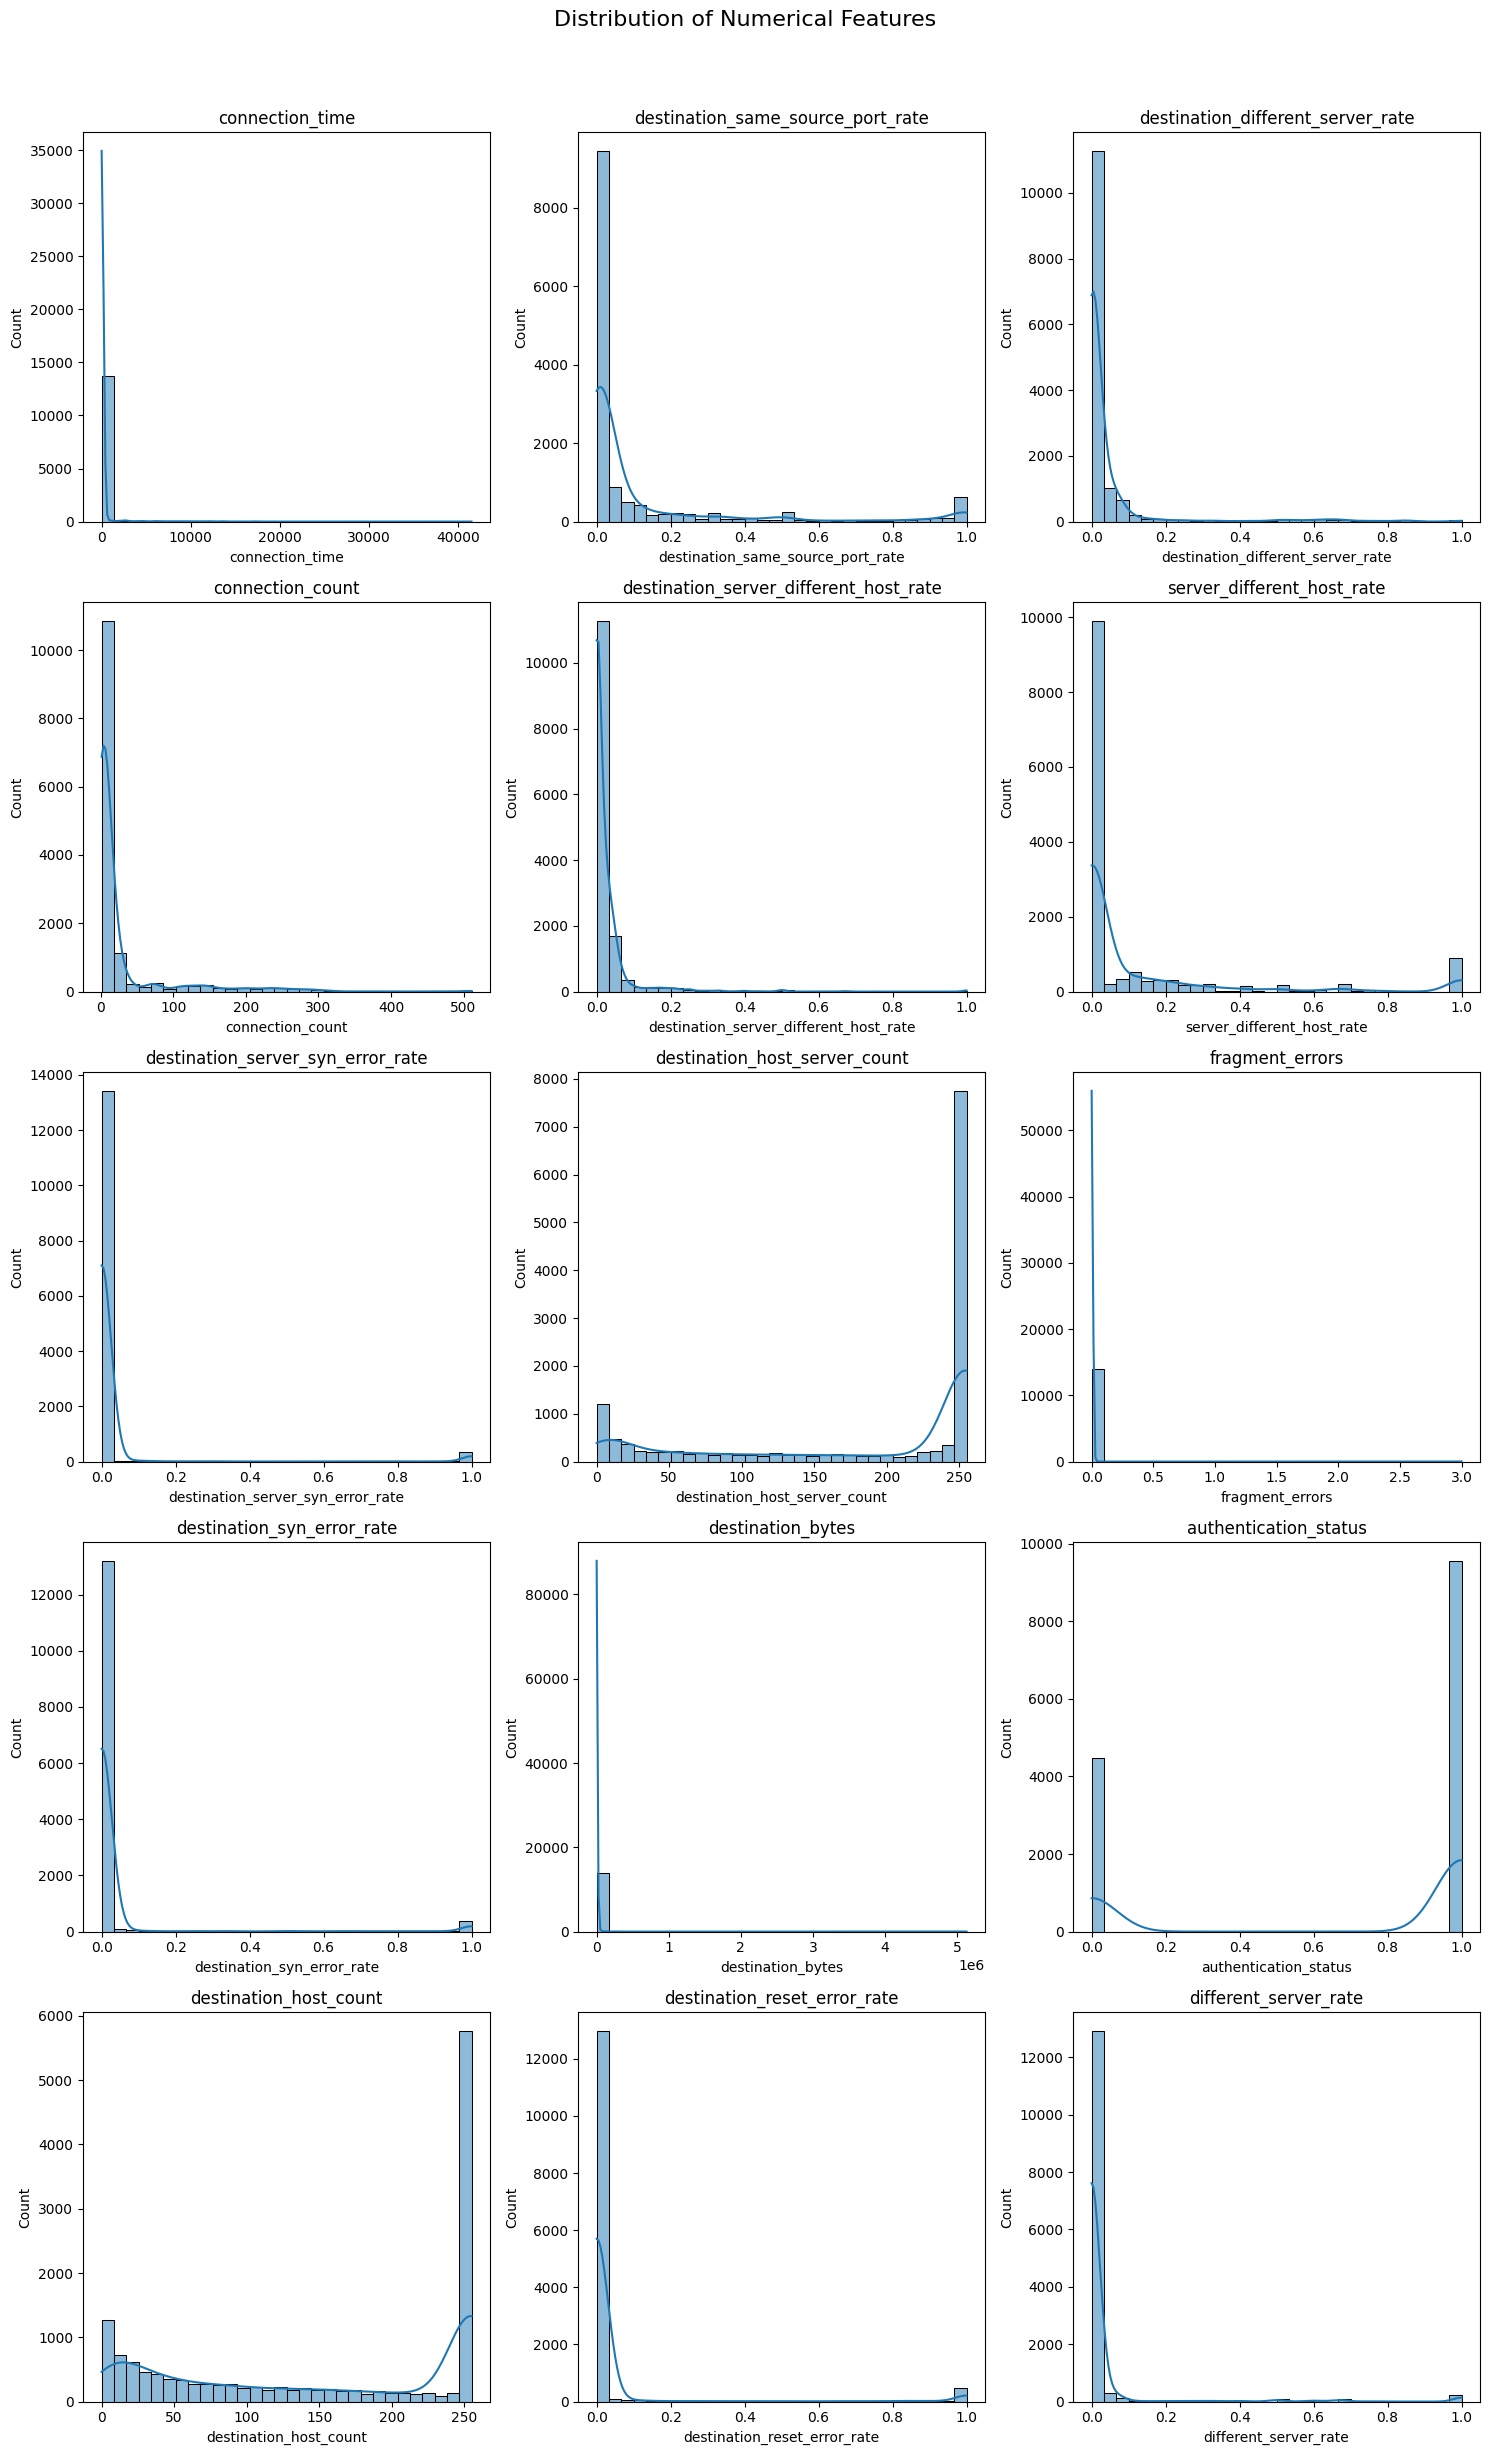

In [14]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = len(numeric_cols)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(num_rows, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer   
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
import numpy as np 
from sklearn.pipeline import Pipeline
# from imblearn.pipeline import Pipeline as ImbPipeline 
# from imblearn.over_sampling import SMOTE

skewed_cols = [
    'connection_time', 'connection_count', 'destination_bytes', 
    'destination_host_server_count', 'destination_host_count', 'fragment_errors'
]

rate_and_binary_cols = [
    'destination_same_source_port_rate', 'destination_different_server_rate',
    'server_different_host_rate', 'destination_server_syn_error_rate',
    'destination_syn_error_rate', 'destination_reset_error_rate',
    'different_server_rate', 'authentication_status'
]

categorical_cols = ['protocol', 'service_type', 'connection_status']

x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=["class"]), df["class"], test_size=0.2, random_state=42)

log_transformer = FunctionTransformer(func=np.log1p, validate=True)
preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, skewed_cols),
        ('pass', 'passthrough', rate_and_binary_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_cols)
    ]
)
logestic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()),
        # ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]
)
logestic_pipeline.fit(x_train, y_train)

y_pred = logestic_pipeline.predict(x_test)


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))




              precision    recall  f1-score   support

     anomaly       0.97      0.92      0.95       126
      normal       1.00      1.00      1.00      2682

    accuracy                           1.00      2808
   macro avg       0.99      0.96      0.97      2808
weighted avg       1.00      1.00      1.00      2808

[[ 116   10]
 [   3 2679]]


In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


y_pred = logestic_pipeline.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)


cm = confusion_matrix(y_test, y_pred)


report = classification_report(y_test, y_pred)


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)


Accuracy : 0.9954
Precision: 0.9953
Recall   : 0.9954
F1 Score : 0.9953

Confusion Matrix:
[[ 116   10]
 [   3 2679]]

Classification Report:
              precision    recall  f1-score   support

     anomaly       0.97      0.92      0.95       126
      normal       1.00      1.00      1.00      2682

    accuracy                           1.00      2808
   macro avg       0.99      0.96      0.97      2808
weighted avg       1.00      1.00      1.00      2808



In [17]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.compose import ColumnTransformer   
# from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
# import numpy as np 

from imblearn.pipeline import Pipeline as ImbPipeline 
from imblearn.over_sampling import SMOTE

skewed_cols = [
    'connection_time', 'connection_count', 'destination_bytes', 
    'destination_host_server_count', 'destination_host_count', 'fragment_errors'
]

rate_and_binary_cols = [
    'destination_same_source_port_rate', 'destination_different_server_rate',
    'server_different_host_rate', 'destination_server_syn_error_rate',
    'destination_syn_error_rate', 'destination_reset_error_rate',
    'different_server_rate', 'authentication_status'
]

categorical_cols = ['protocol', 'service_type', 'connection_status']

x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=["class"]), df["class"], test_size=0.2, random_state=42)

log_transformer = FunctionTransformer(func=np.log1p, validate=True)
preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, skewed_cols),
        ('pass', 'passthrough', rate_and_binary_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_cols)
    ]
)
smote_logestic_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]
)
smote_logestic_pipeline.fit(x_train, y_train)

y_pred = smote_logestic_pipeline.predict(x_test)


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))




              precision    recall  f1-score   support

     anomaly       0.64      0.94      0.76       126
      normal       1.00      0.97      0.99      2682

    accuracy                           0.97      2808
   macro avg       0.82      0.96      0.87      2808
weighted avg       0.98      0.97      0.98      2808

[[ 119    7]
 [  68 2614]]


In [18]:
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score
# )


y_pred = smote_logestic_pipeline.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)


cm = confusion_matrix(y_test, y_pred)


report = classification_report(y_test, y_pred)


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)


Accuracy : 0.9733
Precision: 0.9811
Recall   : 0.9733
F1 Score : 0.9757

Confusion Matrix:
[[ 119    7]
 [  68 2614]]

Classification Report:
              precision    recall  f1-score   support

     anomaly       0.64      0.94      0.76       126
      normal       1.00      0.97      0.99      2682

    accuracy                           0.97      2808
   macro avg       0.82      0.96      0.87      2808
weighted avg       0.98      0.97      0.98      2808



In [20]:
import joblib
joblib.dump(logestic_pipeline, '../models/logestic_regression/logestic_pipeline.pkl')
joblib.dump(smote_logestic_pipeline, '../models/logestic_regression/smote_logestic_pipeline.pkl')

['../models/logestic_regression/smote_logestic_pipeline.pkl']